In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from vis import make_yref, load_border_vertices_xml
# from sklearn.preprocessing import StandardScaler
from util import concat_hrf, group_by_dict_fields
from sklearn.preprocessing import MinMaxScaler
import os
import globals as gl
from pcm_models import find_model, make_planning_models, make_execution_models
import PcmPy as pcm
from scipy.stats import linregress, t, permutation_test
from statsmodels.stats.anova import AnovaRM
from nilearn import surface
import pickle
import pingouin as pg
from matplotlib import colormaps as cm
from scipy.stats import ttest_1samp, pearsonr, ttest_rel
from matplotlib.patches import ConnectionPatch, Rectangle, Patch
from matplotlib.lines import Line2D
import os
import globals as gl
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import pandas as pd
import seaborn as sns
import nibabel as nb
import numpy as np
import nitools as nt
from matplotlib.colors import LinearSegmentedColormap, Normalize
import pyvista as pv
from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel, ttest_1samp

import nitools as nt

plt.style.use('default')

In [19]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'
experiment2 = 'smp0'

In [20]:
from vis import demographics
print('-----Experiment 1:')
_ = demographics(experiment)
print('-----Experiment 2:')
_ = demographics(experiment2)

-----Experiment 1:
Total Participants: 14
Gender Distribution: sex
m    8
f    6
Name: count, dtype: int64
Average Age: 21.357142857142858
SD Age: 4.162232072359232
Age Range: (np.int64(18), np.int64(34))
Handedness Distribution: handedness
right    14
Name: count, dtype: int64
-----Experiment 2:
Total Participants: 10
Gender Distribution: sex
M    8
F    2
Name: count, dtype: int64
Average Age: 25.7
SD Age: 3.7727090178455764
Age Range: (np.int64(21), np.int64(32))
Handedness Distribution: handedness
right    9
left     1
Name: count, dtype: int64


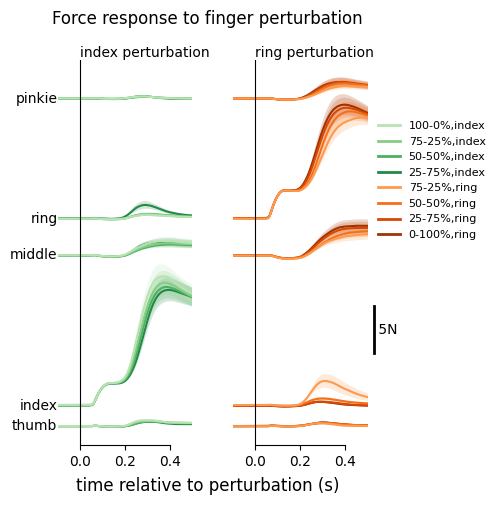

In [21]:
from vis import plot_force_aligned, add_sig_comp_bayes

npz = np.load(os.path.join(gl.baseDir, experiment, gl.behavDir, 'force.segmented.avg.npz'), allow_pickle=True)
force = npz['data_array']
descr = pd.DataFrame(npz['descriptor'].item())
force = force[descr.GoNogo == 'go']
descr = descr[descr.GoNogo == 'go']
fig, axs = plt.subplots(1, 2, figsize=(4, 5), sharey=True, sharex=True)
plot_force_aligned(fig, axs, force, descr)
plt.show()

rmANOVA index
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue 20.7316 3.0000 39.0000 0.0000

rmANOVA ring
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue  7.4148 3.0000 39.0000 0.0005



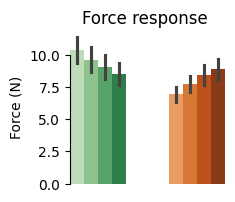

In [22]:
from vis import plot_force_binned

fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(2, 2))
filepath = os.path.join(gl.baseDir, experiment, gl.behavDir, f'{experiment}_force_single_trial.tsv')
dat = pd.read_csv(filepath, sep='\t', )
dat = dat.groupby(['sn', 'cue', 'stimFinger', 'GoNogo', ]).mean(numeric_only=True).reset_index()
fig, axs = plot_force_binned(fig, axs, dat, y=['index1', 'ring1'], finger=('index', 'ring'))
axs[0].spines[['left']].set_bounds(0, 10)
axs[0].set_ylabel('Force (N)')
fig.suptitle('Force response')

anova_index = AnovaRM(data=dat[dat['stimFinger']=='index'], depvar='index1', subject='sn', within=['cue'])
anova_ring = AnovaRM(data=dat[dat['stimFinger']=='ring'], depvar='ring1', subject='sn', within=['cue'])

result = anova_index.fit()
print('rmANOVA index')
print(result)

result = anova_ring.fit()
print('rmANOVA ring')
print(result)

plt.show()

rmANOVA index
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue  3.4133 4.0000 52.0000 0.0149

rmANOVA ring
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue  6.0417 4.0000 52.0000 0.0005



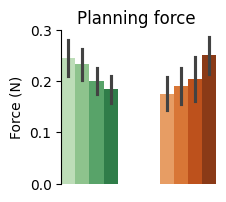

In [23]:
fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(2, 2))
fig, axs = plot_force_binned(fig, axs, dat, y=['index0', 'ring0'])
axs[0].spines[['left']].set_bounds(0, .3)
axs[0].set_ylabel('Force (N)')
fig.suptitle('Planning force')

anova_index = AnovaRM(data=dat[dat['stimFinger']=='nogo'], depvar='index0', subject='sn', within=['cue'])
anova_ring = AnovaRM(data=dat[dat['stimFinger']=='nogo'], depvar='ring0', subject='sn', within=['cue'])

result = anova_index.fit()
print('rmANOVA index')
print(result)

result = anova_ring.fit()
print('rmANOVA ring')
print(result)

plt.show()

[]

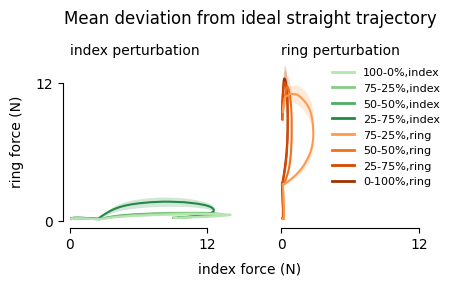

In [24]:
from vis import plot_dev_aligned

fig, axs = plt.subplots(1, 2, figsize=(5, 2.75), sharey=True, sharex=True)
plot_dev_aligned(fig, axs, force, descr)

plt.plot()

rmANOVA index
                 Anova
           F Value Num DF  Den DF Pr > F
----------------------------------------
correspond 17.8907 1.0000 13.0000 0.0010

rmANOVA ring
                 Anova
           F Value Num DF  Den DF Pr > F
----------------------------------------
correspond  6.7472 1.0000 13.0000 0.0221



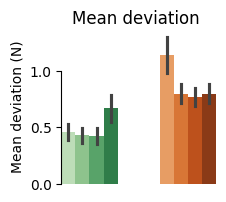

In [25]:
fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(2, 2))
fig, axs = plot_force_binned(fig, axs, dat, y=['MD', 'MD'], finger=('index', 'ring'))
axs[0].spines[['left']].set_bounds(0, 1)
axs[0].set_ylabel('Mean deviation (N)')
dat_stat = dat.copy()
dat_stat['correspond'] = 'high'
mask_low = ((dat_stat['cue'] == '75-25%') & (dat_stat['stimFinger'] == 'ring')) | ((dat_stat['cue'] == '25-75%') & (dat_stat['stimFinger'] == 'index'))
dat_stat.loc[mask_low, 'correspond'] = 'low'
dat_stat = dat_stat[dat_stat['GoNogo'] == 'go']

dat_stat = dat_stat.groupby(['sn', 'stimFinger', 'GoNogo','correspond']).mean(numeric_only=True).reset_index()

anova_index = AnovaRM(data=dat_stat[dat_stat['stimFinger']=='index'], depvar='index1', subject='sn', within=['correspond'])
anova_ring = AnovaRM(data=dat_stat[dat_stat['stimFinger']=='ring'], depvar='ring1', subject='sn', within=['correspond'])

result = anova_index.fit()
print('rmANOVA index')
print(result)

result = anova_ring.fit()
print('rmANOVA ring')
print(result)

fig.suptitle('Mean deviation')

plt.show()

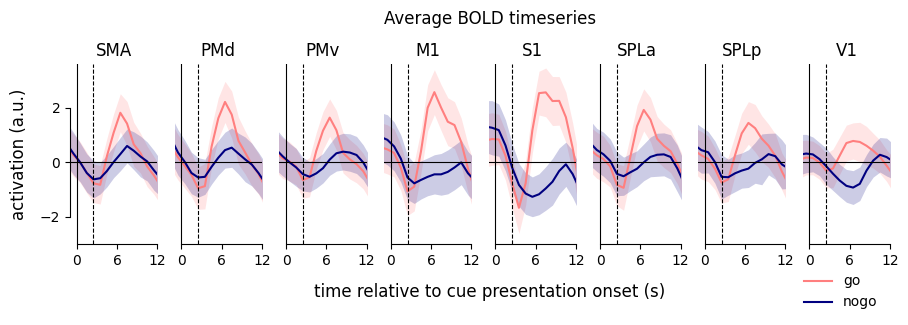

In [26]:
from vis import plot_bold

H = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
sns = [102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115]
Ts = [os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}', 'T.mat') for sn in sns]
T = concat_hrf(Ts)

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(10, 3))
fig, axs = plot_bold(fig, axs, T, H, rois)

plt.show()

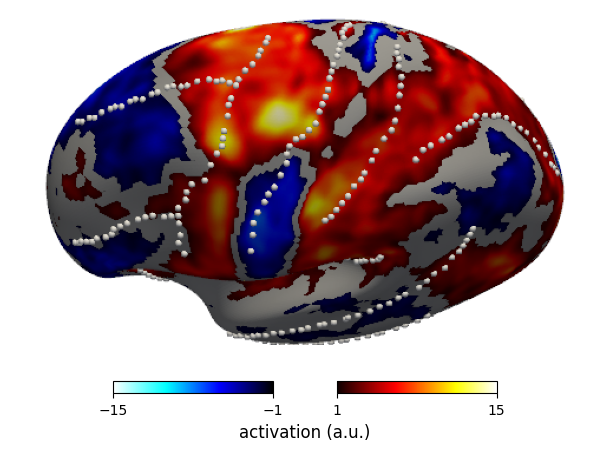

In [27]:
from vis import plot_surf

cold_colors = [(0, 0, 0), (0, 0, 1), (0, 1, 1), (1, 1, 1)]  # RGB tuples
cold = LinearSegmentedColormap.from_list('cold_custom', cold_colors, N=128)
hot = plt.cm.hot(np.linspace(0, 1, 128))
cold_vals = cold(np.linspace(1, 0, 128))  # reversed
combined = np.vstack((cold_vals, hot))
cmap = LinearSegmentedColormap.from_list('coldhot', combined)

dtype = 'con'
H = 'L'
thresh = 1
vmin, vmax = -15, 15

cifti = nb.load(os.path.join(gl.baseDir, experiment, gl.wbDir, f'glm{glm}.{dtype}.plan-exec.smooth.dscalar.nii'))
fig, ax = plt.subplots()
fig, ax = plot_surf(fig, ax, cifti, H, cmap=cmap, col=0, thresh=thresh, vmin=vmin, vmax=vmax)

cold_half = LinearSegmentedColormap.from_list("cold_half", combined[:128])
hot_half = LinearSegmentedColormap.from_list("hot_half", combined[128:])

neg_norm = Normalize(vmin=vmin, vmax=-thresh)
sm_neg = ScalarMappable(norm=neg_norm, cmap=cold_half)
cax_neg = fig.add_axes([0.2, 0.1, 0.25, 0.025])
cbar_neg = fig.colorbar(sm_neg, ax=ax, cax=cax_neg, fraction=0.03, pad=0.02, orientation='horizontal')
cbar_neg.set_ticks([vmin, -thresh])
fig.supxlabel('activation (a.u.)', y=.001)

pos_norm = Normalize(vmin=thresh, vmax=vmax)
sm_pos = ScalarMappable(norm=pos_norm, cmap=hot_half)
cax_pos = fig.add_axes([0.55, 0.1, 0.25, 0.025])
cbar_pos = fig.colorbar(sm_pos, ax=ax, cax=cax_pos, fraction=0.03, pad=0.08, orientation='horizontal')
cbar_pos.set_ticks([thresh, vmax])
plt.subplots_adjust(left=0, right=1, bottom=.2, top=.9)

plt.show()

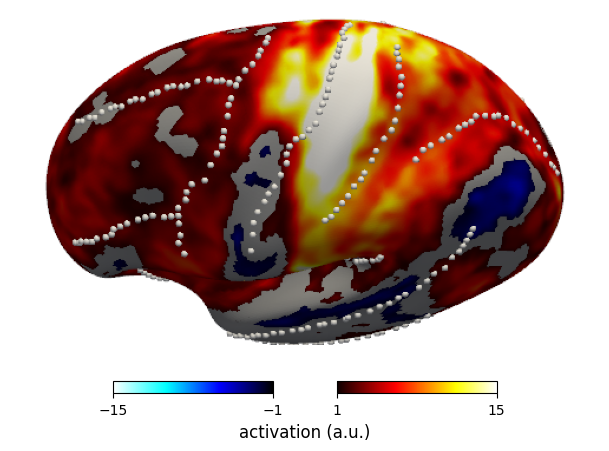

In [28]:
fig, ax = plt.subplots()
fig, ax = plot_surf(fig, ax, cifti, 'L', cmap=cmap, col=1, thresh=thresh, vmin=vmin, vmax=vmax)

cax_neg = fig.add_axes([0.2, 0.1, 0.25, 0.025])
cbar_neg = fig.colorbar(sm_neg, ax=ax, cax=cax_neg, fraction=0.03, pad=0.02, orientation='horizontal')
cbar_neg.set_ticks([vmin, -thresh])
fig.supxlabel('activation (a.u.)', y=.001)

cax_pos = fig.add_axes([0.55, 0.1, 0.25, 0.025])
cbar_pos = fig.colorbar(sm_pos, ax=ax, cax=cax_pos, fraction=0.03, pad=0.08, orientation='horizontal')
cbar_pos.set_ticks([thresh, vmax])
plt.subplots_adjust(left=0, right=1, bottom=.2, top=.9)

plt.show()

ROI: SMA
planning vs. execution: tval=-0.3229932285250466, pval=0.7518367389243134
planning vs. 0: tval=3.0501993503244074, pval=0.00929641152551975
execution vs. 0: tval=2.8844843668975733, pval=0.012782937696076468
ROI: PMd
planning vs. execution: tval=-0.4780356934286871, pval=0.6405632164210409
planning vs. 0: tval=3.886242012611708, pval=0.0018743355566448975
execution vs. 0: tval=4.482046703653322, pval=0.0006172528156846847
ROI: PMv
planning vs. execution: tval=-0.6179286255988247, pval=0.5472955590172652
planning vs. 0: tval=3.5352843332538777, pval=0.003658089075464079
execution vs. 0: tval=2.7611488387710907, pval=0.016189211246084075
ROI: M1
planning vs. execution: tval=1.796478084065509, pval=0.09568112110267324
planning vs. 0: tval=2.8121366650325212, pval=0.014684526345514723
execution vs. 0: tval=6.848729354222539, pval=1.1725664423993211e-05
ROI: S1
planning vs. execution: tval=4.608984772840678, pval=0.0004896361254904716
planning vs. 0: tval=0.7258302279090869, pval=0

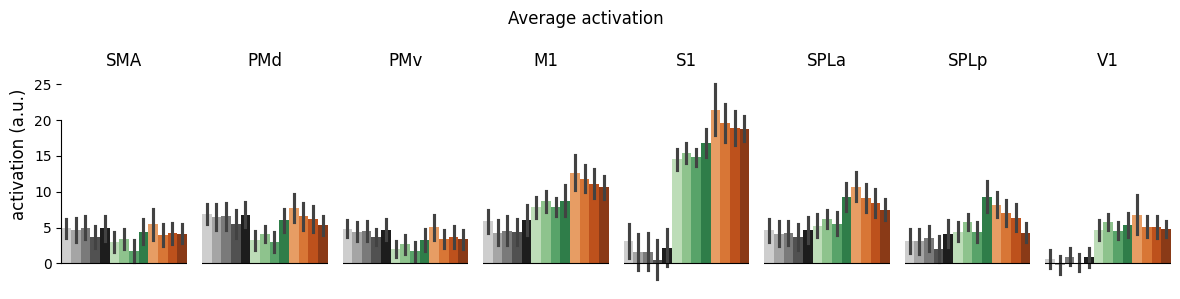

In [29]:
from vis import plot_avg_activation

df_con = pd.read_csv(os.path.join(gl.baseDir, experiment, f'glm{glm}','ROI.con.avg.tsv'), sep='\t')
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(12, 3))
fig, axs = plot_avg_activation(fig, axs, df_con, H, rois)
axs[0].spines[['left', ]].set_bounds(0, 20)
df_con_stat = df_con.groupby(['sn', 'roi', 'Hem', 'epoch']).mean(numeric_only=True).reset_index()
for roi in rois:
    plan = df_con_stat[(df_con_stat['roi'] == roi) & (df_con_stat['Hem'] == H) & (df_con_stat['epoch'] == 'plan')]['con']
    exec = df_con_stat[(df_con_stat['roi'] == roi) & (df_con_stat['Hem'] == H) & (df_con_stat['epoch'] == 'exec')]['con']
    print(f'ROI: {roi}')
    tval, pval = ttest_rel(exec, plan)
    print(f'planning vs. execution: tval={tval}, pval={pval}')
    tval, pval = ttest_1samp(plan, 0)
    print(f'planning vs. 0: tval={tval}, pval={pval}')
    tval, pval = ttest_1samp(exec, 0)
    print(f'execution vs. 0: tval={tval}, pval={pval}')
fig.supylabel('activation (a.u.)')
fig.suptitle(f'Average activation')
fig.tight_layout()

SMA: tval=3.5010671094999073, pval=0.0039060453412955018
PMd: tval=4.598273847949548, pval=0.0004992619554198543
PMv: tval=5.3808301566361045, pval=0.000125187622886593
M1: tval=4.899815837755327, pval=0.00029019207531803896
S1: tval=7.019441292795594, pval=9.074145112011435e-06
SPLa: tval=4.418617091916282, pval=0.000693485040952692
SPLp: tval=6.069299768949967, pval=3.972784835483162e-05
V1: tval=4.609133471596346, pval=0.0004895038538421373


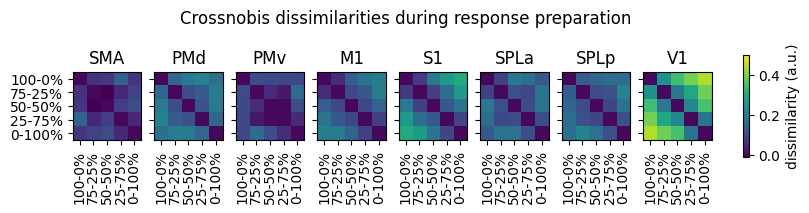

In [30]:
from vis import plot_dissimilarities

vmin, vmax = -.01, .5

fig, axs = plt.subplots(1, len(rois), figsize=(8, 2),sharex=True, sharey=True, constrained_layout=True)
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G)
    fig, axs = plot_dissimilarities(fig, axs, r, D, list(gl.regressor_mapping.keys())[:5], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle('Crossnobis dissimilarities during response preparation')

plt.show()

SMA: tval=0.9962453549336798, pval=0.3373138956673887
PMd: tval=4.443834631241265, pval=0.0006620735305390923
PMv: tval=3.060203046428879, pval=0.00911916953058987
M1: tval=4.708603133738999, pval=0.0004088190388094659
S1: tval=6.461535784425369, pval=2.1276755736041283e-05
SPLa: tval=3.659399403711794, pval=0.0028850835740599884
SPLp: tval=4.995246245404956, pval=0.000245003537284224
V1: tval=4.426955917075241, pval=0.0006829309338037777


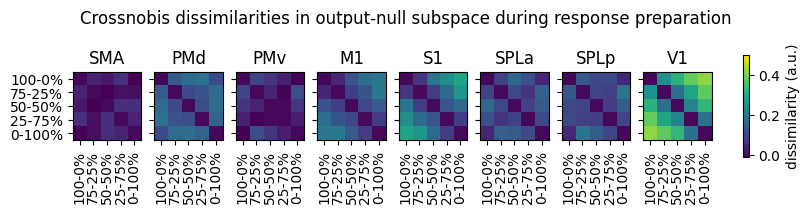

In [31]:
from vis import plot_dissimilarities

vmin, vmax = -.01, .5

fig, axs = plt.subplots(1, len(rois), figsize=(8, 2),sharex=True, sharey=True, constrained_layout=True)
tr_null_plan, tr_pot_plan = [], []
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.null.plan.glm{glm}.{H}.{roi}.npy'))
    tr_null_plan.append(np.trace(G, axis1=1, axis2=2))
    D = pcm.G_to_dist(G)
    fig, axs = plot_dissimilarities(fig, axs, r, D, list(gl.regressor_mapping.keys())[:5], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle('Crossnobis dissimilarities in output-null subspace during response preparation')

plt.show()

SMA: tval=5.351735070997867, pval=0.0001316005451242958
PMd: tval=4.4140629762748285, pval=0.0006993200579191706
PMv: tval=6.20599153273635, pval=3.1881606364090525e-05
M1: tval=3.275081026956169, pval=0.006030025950040107
S1: tval=4.772062627922034, pval=0.0003646756019907246
SPLa: tval=5.3747402424012085, pval=0.00012650231118333443
SPLp: tval=4.41258002001344, pval=0.0007012310503968872
V1: tval=2.8018805765462664, pval=0.014975716654242506


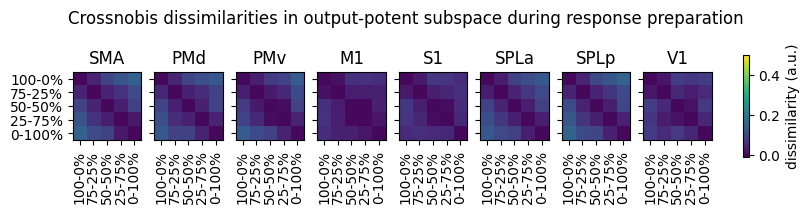

In [32]:
from vis import plot_dissimilarities

vmin, vmax = -.01, .5

fig, axs = plt.subplots(1, len(rois), figsize=(8, 2),sharex=True, sharey=True, constrained_layout=True)
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.pot.plan.glm{glm}.{H}.{roi}.npy'))
    tr_pot_plan.append(np.trace(G, axis1=1, axis2=2))
    D = pcm.G_to_dist(G)
    fig, axs = plot_dissimilarities(fig, axs, r, D, list(gl.regressor_mapping.keys())[:5], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle('Crossnobis dissimilarities in output-potent subspace during response preparation')

plt.show()

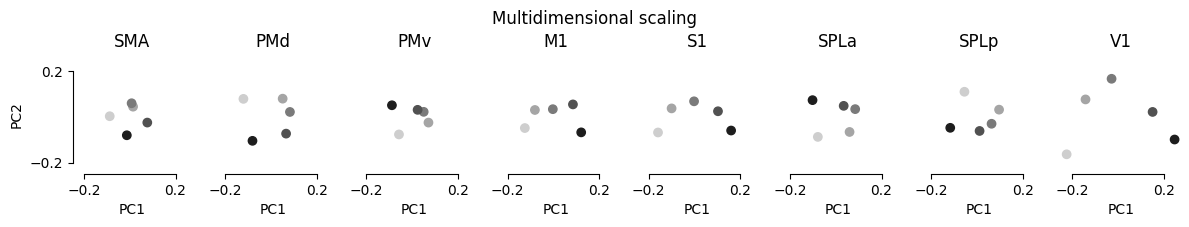

In [33]:
fig, axs = plt.subplots(1, len(rois), figsize=(12, 2),sharex=True, sharey=True, constrained_layout=True)
for r, roi in enumerate(rois):
    ax=axs[r]
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    mds, _ = pcm.classical_mds(G.mean(axis=0))
    ax.scatter(mds[:, 0], mds[:, 1], color=list(gl.colour_mapping.values())[:5])
    ax.set_aspect('equal')
    ax.set_ylim(ax.get_xlim())
    ax.set_xlabel('PC1')
    ax.set_title(roi)
    ax.set_xticks([-.2, .2])
    ax.set_yticks(ax.get_xticks())
    ax.spines[['left', 'top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_bounds(-.2, .2)
    if r==0:
        ax.spines['left'].set_visible(True)
        ax.set_ylabel('PC2')
    else:
        ax.tick_params(axis='y', left=False)

fig.suptitle('Multidimensional scaling')
fig.tight_layout()

plt.show()

SMA: 0.7613832223037056 upper noise
PMd: 0.9376384776352877 upper noise
PMv: 0.868869080770446 upper noise
M1: 0.9475113617529994 upper noise
S1: 0.9703536254816323 upper noise
SPLa: 0.8531673965000695 upper noise
SPLp: 0.8974235854019855 upper noise
V1: 0.9199283484760543 upper noise
SMA, tval=2.4721544692160515, pval=0.014010428959561463
PMd, tval=2.6191278323072638, pval=0.010610625582357602
PMv, tval=2.9335941019013534, pval=0.005816393003053961
M1, tval=2.503513281271605, pval=0.013206594117807308
S1, tval=3.507789309996103, pval=0.0019280121560048245
SPLa, tval=1.9706309013582286, pval=0.035220859287201166
SPLp, tval=3.526368773601209, pval=0.0018605590714114515
V1, tval=3.7474181810635967, pval=0.0012197178185510075


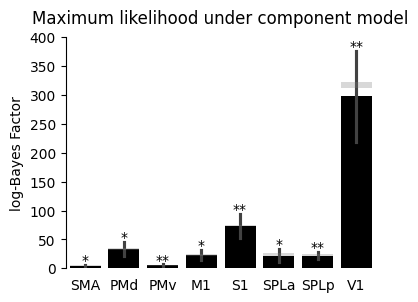

In [34]:
from vis import plot_likelihood

LL = {'roi': [],'noise_upper': [],'noise_lower': [],'baseline': [],'likelihood': [],}
for roi in rois:
    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.plan.glm{glm}.{H}.{roi}.p'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.plan.glm{glm}.{H}.{roi}.p'))
    LL['likelihood'].extend(T_cv.likelihood['component'])
    LL['baseline'].extend(T_cv.likelihood['null'])
    LL['roi'].extend([roi] * len(T_cv.likelihood['component']))
    LL['noise_upper'].extend(T_gr.likelihood['ceil'])
    LL['noise_lower'].extend(T_cv.likelihood['ceil'])

fig, axs = plt.subplots(figsize=(4, 3))
fig, axs = plot_likelihood(fig, axs, LL, x='roi')
axs.set_ylim(0, 400)
axs.set_title('Maximum likelihood under component model', pad=10)
plt.show()


SMA:
cue, tval=1.0818559353326722, pval=0.149488394941478
uncertainty, tval=1.5702326337239747, pval=0.07018639786492221
cue vs. uncertainty, tval=-0.42614477493982517, pval=0.6769735785612773

PMd:
cue, tval=3.697105903715779, pval=0.0013424093043880691
uncertainty, tval=3.266502671576634, pval=0.0030651994603195635
cue vs. uncertainty, tval=-0.647931178621074, pval=0.5283075487949269

PMv:
cue, tval=1.6184859330964738, pval=0.06477619505224474
uncertainty, tval=2.1240961008671952, pval=0.02671037988947194
cue vs. uncertainty, tval=-1.1080193714154183, pval=0.28793299017519675

M1:
cue, tval=3.3053714746981053, pval=0.0028443138634020714
uncertainty, tval=1.4209716399729575, pval=0.08943297606876835
cue vs. uncertainty, tval=2.9338757548007606, pval=0.01162649411976888

S1:
cue, tval=6.930914079433891, pval=5.179666211261685e-06
uncertainty, tval=2.1646767080704676, pval=0.024803809958161827
cue vs. uncertainty, tval=4.056131896812188, pval=0.0013606149995194683

SPLa:
cue, tval=3.03

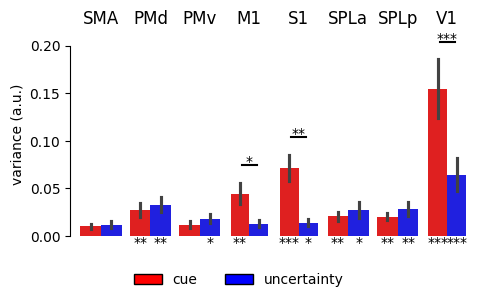

In [60]:
from vis import plot_var_expl, add_sig_var_expl

Mc, idxc = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan.p'), 'component')
n_param_c = Mc.n_param
components = ['cue', 'uncertainty']
palette = ['red', 'blue']
MF = pcm.model.ModelFamily(Mc.Gc, comp_names=components,)
fig, axs = plt.subplots(1, len(rois), figsize=(5, 3), sharey=True, )
for r, roi in enumerate(rois):
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.plan.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    fig, axs = plot_var_expl(fig, axs, r, param_c, components=components, palette=palette)
for r, roi in enumerate(rois):
    print(f'\n{roi}:')
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.plan.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    T = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T.model_family.plan.glm{glm}.{H}.{roi}.p'))
    c_bf = MF.component_bayesfactor(T.likelihood, method='AIC', format='DataFrame')
    fig, axs = add_sig_comp_bayes(fig, axs, r, c_bf)
    fig, axs = add_sig_var_expl(fig, axs, r, param_c, components)
    axs[r].set_title(roi)
legend_handles = [Patch(facecolor=col, edgecolor='black', label=comp) for comp, col in zip(components, palette)]
fig.legend(handles=legend_handles, loc='lower center', frameon=False, ncol=len(components), fontsize=10)
fig.subplots_adjust(bottom=.2)
axs[0].spines['left'].set_bounds(axs[0].get_yticks()[0], axs[0].get_yticks()[-2])
plt.show()

M1-S1/prem-pariet ratio, tval=4.856624372856906, pval=0.0003134209615975897


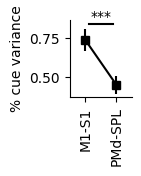

In [73]:
rois_prim = ['M1', 'S1']
rois_high = ['PMd', 'SPLa', 'SPLp']

var_expl_prim = []
for roi in rois_prim:
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.plan.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    var_expl_prim.append(np.exp(param_c))

var_expl_high = []
for roi in rois_high:
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.plan.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    var_expl_high.append(np.exp(param_c))

var_expl_prim = np.array(var_expl_prim).mean(axis=0)
var_expl_high = np.array(var_expl_high).mean(axis=0)
ratio_prim = var_expl_prim[0] / (var_expl_prim[1] + var_expl_prim[0])
ratio_high = var_expl_high[0] / (var_expl_high[1] + var_expl_high[0])
ratio = np.c_[ratio_prim, ratio_high]
ratio_avg = ratio.mean(axis=0)
ratio_err = ratio.std(axis=0) / np.sqrt(ratio.shape[0])

fig, ax = plt.subplots(figsize=(.8, 1))

ax.errorbar(['M1-S1', 'PMd-SPL'], ratio_avg, yerr=ratio_err, color='k', marker='s')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xticklabels(labels=['M1-S1', 'PMd-SPL'], rotation=90)
ax.set_ylabel('% cue variance')
ax.set_xlim(-.5, 1.5)

tval, pval = ttest_rel(ratio[:, 0], ratio[:, 1], alternative='two-sided')
print(f"M1-S1/prem-pariet ratio, tval={tval}, pval={pval}")
if pval < 0.001:
    stars = '***'
elif pval < 0.01:
    stars = '**'
elif pval < 0.05:
    stars = '*'
else:
    stars = None
if stars:
    y_max = ratio.mean(axis=0).max()
    y_argmax = ratio.mean(axis=0).argmax()
    se = ratio[y_argmax].std() / np.sqrt(ratio.shape[0])
    y_max += se
    y_max0 = y_max
    center = .5
    x1 = center - .4
    x2 = center + .4
    offset = .1 * ax.get_ylim()[1]
    ax.plot([x1, x2], [y_max + offset , y_max + offset], lw=1.5, c='k')
    ax.text(center, y_max + offset, stars, ha='center', va='bottom', fontsize=10)

plt.show()

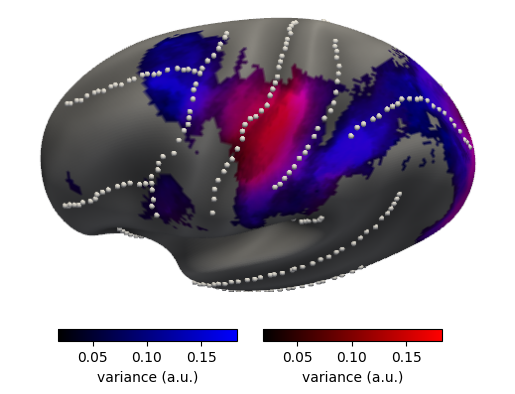

In [37]:
mclip = .3
threshold = .1 / mclip
scaler = MinMaxScaler()

gifti = nb.load(os.path.join(gl.baseDir, experiment, gl.wbDir, f'searchlight.var_expl.plan.{H}.func.gii'))
data = nt.get_gifti_data_matrix(gifti)
raw_max = np.nanmax(data)
data = scaler.fit_transform(data)
raw_min = scaler.inverse_transform([[threshold * mclip, threshold * mclip]])[0,0]
data = np.clip(data / mclip, 0, 1)

sulc = nt.get_gifti_data_matrix(nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.LR.sulc.dscalar.gii'))
sulc = sulc[:len(data)]
sulc_norm = MinMaxScaler((0.3, 0.7)).fit_transform(sulc.reshape(-1, 1)).flatten()

rgba = np.zeros((len(sulc_norm), 4))
rgba[:, 0] = sulc_norm  # red = grey
rgba[:, 1] = sulc_norm  # green = grey
rgba[:, 2] = sulc_norm  # blue = grey
rgba[:, 3] = 1.0        # opaque background

overlay_mask = (data[:, 0] >= threshold) | (data[:, 1] >= threshold)

rgba[overlay_mask, 0] = data[overlay_mask, 0]  # red
rgba[overlay_mask, 1] = 0                    # green stays off for 2-color blend
rgba[overlay_mask, 2] = data[overlay_mask, 1]  # blue
rgba[overlay_mask, 3] = 1.0                     # alpha: opaque overlay
rgba[~overlay_mask, 3] = 1.0                    # still show grey background

fig, ax = plt.subplots()
fig, ax = plot_surf(fig, ax, rgba, H, cmap=None, vmin=None, vmax=None, overlay='rgb')

blue_half = LinearSegmentedColormap.from_list("blue_half", ["black", "blue"])
neg_norm = Normalize(vmin=raw_min, vmax=raw_max)
sm_neg = ScalarMappable(norm=neg_norm, cmap=blue_half)

red_half = LinearSegmentedColormap.from_list("red_half", ["black", "red"])
pos_norm = Normalize(vmin=raw_min, vmax=raw_max)
sm_pos = ScalarMappable(norm=pos_norm, cmap=red_half)

cax_neg = fig.add_axes([0.20, 0.10, 0.28, 0.025])  # left (blue)
cax_pos = fig.add_axes([0.52, 0.10, 0.28, 0.025])  # right (red)

cbar_neg = fig.colorbar(sm_neg, cax=cax_neg, orientation='horizontal')
cbar_pos = fig.colorbar(sm_pos, cax=cax_pos, orientation='horizontal')

cbar_neg.set_label('variance (a.u.)')
cbar_pos.set_label('variance (a.u.)')

plt.show()

force: tval=3.2106057951069467, pval=0.006826772009600081


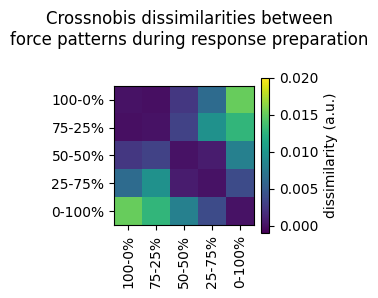

In [38]:
fig, ax = plt.subplots(figsize=(2, 3))

vmin, vmax = -.001, .02

G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.force.plan.npy'))
D = pcm.G_to_dist(G)
fig, ax = plot_dissimilarities(fig, ax, None, D, list(gl.regressor_mapping.keys())[:5], vmin=vmin, vmax=vmax, sqrt=True, source='force')
cax = ax.get_images()[0]
cbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=.05)
cbar.set_label('dissimilarity (a.u.)')

fig.suptitle('Crossnobis dissimilarities between\nforce patterns during response preparation')

plt.show()


M1
slope: -0.12653173511040539, p = 0.309
intercept: 0.031146191554357716, p_intercept = 0.001
R2 = 0.086

S1
slope: -0.021014313874710082, p = 0.869
intercept: 0.03726382575972054, p_intercept = 0.001
R2 = 0.002


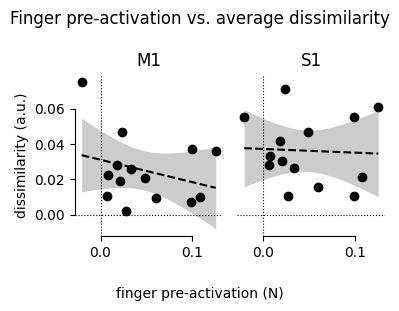

In [39]:
from vis import plot_correlation

rois_tmp = ['M1', 'S1']
diff = np.zeros(len(sns))
pcm_path = os.path.join(gl.baseDir, experiment, gl.pcmDir)
for s, sn in enumerate(sns):
    dat = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}.dat'), sep='\t')
    dat = dat[(dat['cue']==93) | (dat['cue']==39)]
    diff[s] = dat['forceDiff'].mean()

fig, axs = plt.subplots(1, len(rois_tmp), sharex=True, sharey=True, figsize=(4, 3))

for r, roi in enumerate(rois_tmp):
    print(f'\n{roi}')
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G)
    x = diff
    y = D.mean(axis=(1, 2))
    fig, axs =  plot_correlation(fig, axs, r, x, y, alternative_slope='two-sided', alternative_intercept='two-sided')
    axs[r].set_title(roi)

for ax in axs:
    yticks = ax.get_yticks()
    xticks = ax.get_xticks()
    ax.spines['left'].set_bounds(yticks[1], yticks[-2])
    ax.spines['bottom'].set_bounds(xticks[1], xticks[-2])

axs[0].set_ylabel('dissimilarity (a.u.)', fontsize=10)
axs[1].tick_params('y', left=False)
fig.supxlabel('finger pre-activation (N)', fontsize=10)

fig.suptitle('Finger pre-activation vs. average dissimilarity')

fig.tight_layout()

plt.show()

SMA: tval=3.7412524069250153, pval=0.002468235301479197
PMd: tval=4.632755946072445, pval=0.00046895451287191274
PMv: tval=4.871751027995077, pval=0.000305072938977274
M1: tval=4.855534566185381, pval=0.00031403150734821367
S1: tval=4.095856035259803, pval=0.0012629113949307223
SPLa: tval=4.6441182080136745, pval=0.000459391177882726
SPLp: tval=5.413064990715796, pval=0.00011846310171498154
V1: tval=6.05917091153094, pval=4.038503715694297e-05


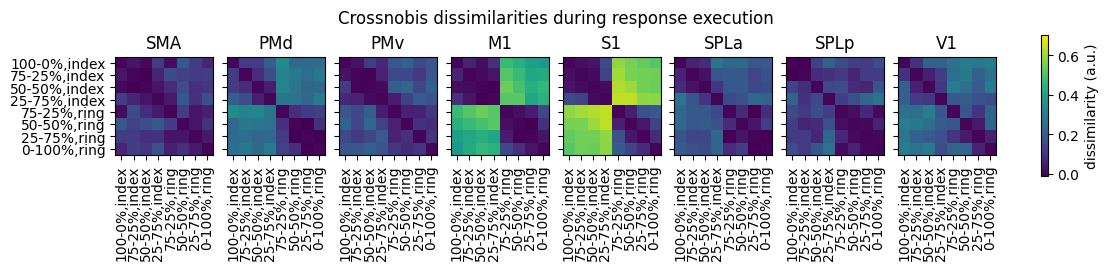

In [40]:
vmin, vmax = -.01, .7

fig, axs = plt.subplots(1, len(rois), figsize=(11, 2.5),sharex=True, sharey=True, constrained_layout=True)
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.exec.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G)
    fig, axs = plot_dissimilarities(fig, axs, r, D, list(gl.regressor_mapping.keys())[5:13], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle('Crossnobis dissimilarities during response execution')

plt.show()

SMA: tval=-4.722892839072925, pval=0.000398416635601096
PMd: tval=-6.3603209994406615, pval=2.494617959456817e-05
PMv: tval=-5.762627462717739, pval=6.570298534566074e-05
M1: tval=-1.847694011699213, pval=0.08752176089160663
S1: tval=0.4363741721132066, pval=0.6697248740896605
SPLa: tval=-5.742808050845787, pval=6.790499001696929e-05
SPLp: tval=-4.40605397691276, pval=0.0007097051230958649
V1: tval=-2.978601604283843, pval=0.0106689481644793


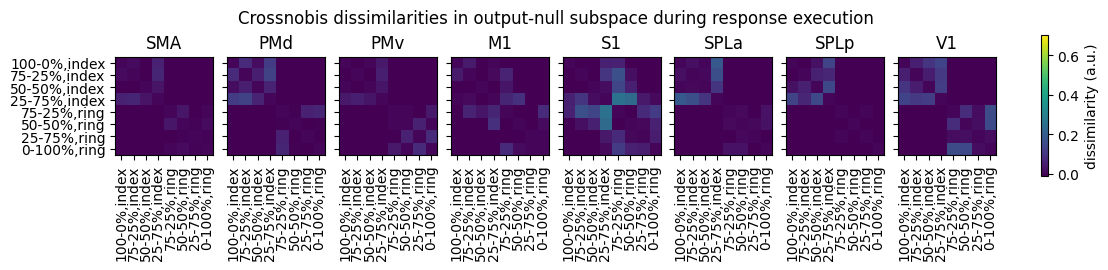

In [41]:
vmin, vmax = -.01, .7

fig, axs = plt.subplots(1, len(rois), figsize=(11, 2.5),sharex=True, sharey=True, constrained_layout=True)
tr_null_exec, tr_pot_exec = [], []
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.null.exec.glm{glm}.{H}.{roi}.npy'))
    tr_null_exec.append(np.trace(G, axis1=1, axis2=2))
    D = pcm.G_to_dist(G)
    fig, axs = plot_dissimilarities(fig, axs, r, D, list(gl.regressor_mapping.keys())[5:13], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle('Crossnobis dissimilarities in output-null subspace during response execution')

plt.show()

SMA: tval=6.6679902102096795, pval=1.5446779496358886e-05
PMd: tval=6.258547243742199, pval=2.9315681943502644e-05
PMv: tval=7.553783344662444, pval=4.167654364523308e-06
M1: tval=6.6517945946897505, pval=1.583641246654915e-05
S1: tval=5.751602890166846, pval=6.691843581053738e-05
SPLa: tval=7.061193250518435, pval=8.52764891745303e-06
SPLp: tval=6.2244936988656, pval=3.095227472165064e-05
V1: tval=7.9490954402179685, pval=2.3978697082925586e-06


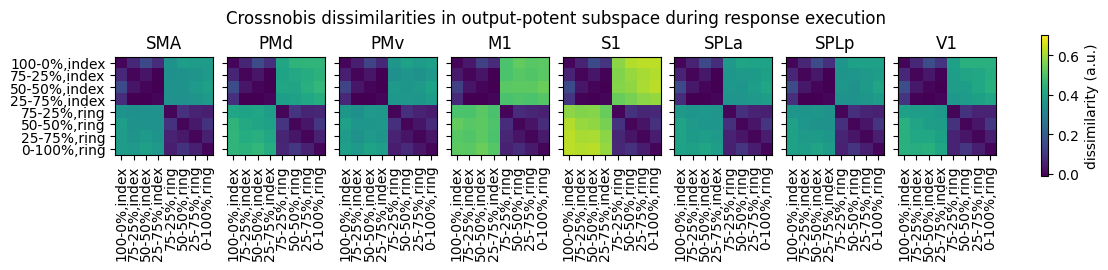

In [42]:
vmin, vmax = -.01, .7

fig, axs = plt.subplots(1, len(rois), figsize=(11, 2.5),sharex=True, sharey=True, constrained_layout=True)
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.pot.exec.glm{glm}.{H}.{roi}.npy'))
    tr_pot_exec.append(np.trace(G, axis1=1, axis2=2))
    D = pcm.G_to_dist(G)
    fig, axs = plot_dissimilarities(fig, axs, r, D, list(gl.regressor_mapping.keys())[5:13], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle('Crossnobis dissimilarities in output-potent subspace during response execution')

plt.show()

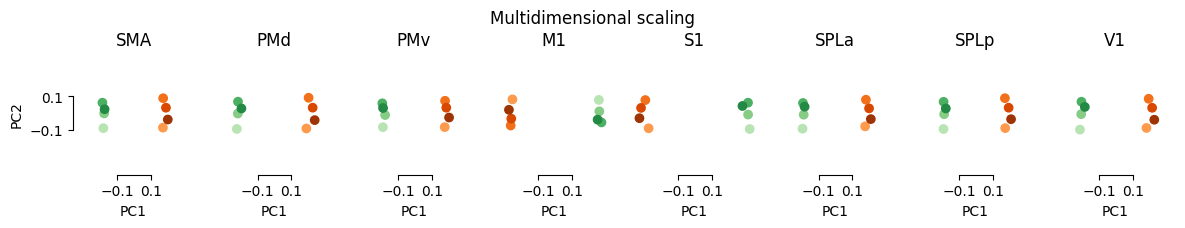

In [43]:
fig, axs = plt.subplots(1, len(rois), figsize=(12, 2),sharex=True, sharey=True, constrained_layout=True)
for r, roi in enumerate(rois):
    ax=axs[r]
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.pot.exec.glm{glm}.{H}.{roi}.npy'))
    mds, _ = pcm.classical_mds(G.mean(axis=0))
    ax.scatter(mds[:, 0], mds[:, 1], color=list(gl.colour_mapping.values())[5:13])
    ax.set_aspect('equal')
    ax.set_ylim(ax.get_xlim())
    ax.set_xlabel('PC1')
    ax.set_title(roi)
    ax.set_xticks([-.1, .1])
    ax.set_yticks(ax.get_xticks())
    ax.spines[['left', 'top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_bounds(-.1, .1)
    if r==0:
        ax.spines['left'].set_visible(True)
        ax.set_ylabel('PC2')
    else:
        ax.tick_params(axis='y', left=False)

fig.suptitle('Multidimensional scaling')
fig.tight_layout()

plt.show()

In [44]:
tr_null_plan = np.clip(np.array(tr_null_plan), 0, np.inf)
tr_pot_plan = np.clip(np.array(tr_pot_plan), 0, np.inf)
tr_null_exec = np.clip(np.array(tr_null_exec), 0, np.inf)
tr_pot_exec = np.clip(np.array(tr_pot_exec), 0, np.inf)

df = pd.DataFrame()
df['rois'] = rois * tr_null_plan.shape[1]
df['sn'] = np.repeat(np.arange(tr_null_plan.shape[1]), len(rois))


SMA: 0.08627241973449397 upper noise
PMd: 0.1061649501469042 upper noise
PMv: 0.13549275607682332 upper noise
M1: 0.5721616100253766 upper noise
S1: 0.6714000669166603 upper noise
SPLa: 0.11547842661792634 upper noise
SPLp: 0.11487708103642459 upper noise
V1: 0.03349374601397325 upper noise
SMA, tval=3.4248951595032024, pval=0.002260435180419244
PMd, tval=6.5840325231885055, pval=8.791424401602628e-06
PMv, tval=4.271620838983672, pval=0.0004549598405633233
M1, tval=3.7833776351151904, pval=0.0011390826854641286
S1, tval=4.006453332622701, pval=0.0007469098026276818
SPLa, tval=4.497945876455558, pval=0.0002997700835360881
SPLp, tval=2.6662154710232424, pval=0.00970181683697406
V1, tval=1.9319750510374787, pval=0.037726433826052896


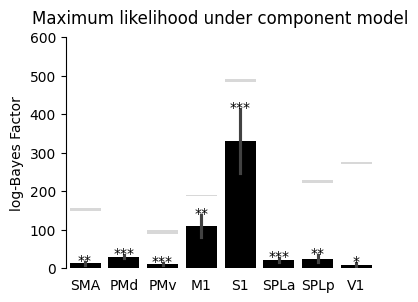

In [45]:
LL = {'roi': [],'noise_upper': [],'noise_lower': [],'baseline': [],'likelihood': [],}
for roi in rois:
    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.exec.glm{glm}.{H}.{roi}.p'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.exec.glm{glm}.{H}.{roi}.p'))
    LL['likelihood'].extend(T_cv.likelihood['component'])
    LL['baseline'].extend(T_cv.likelihood['null'])
    LL['roi'].extend([roi] * len(T_cv.likelihood['component']))
    LL['noise_upper'].extend(T_gr.likelihood['ceil'])
    LL['noise_lower'].extend(T_cv.likelihood['ceil'])

fig, axs = plt.subplots(figsize=(4, 3))
fig, axs = plot_likelihood(fig, axs, LL, x='roi')
axs.set_ylim(0, 600)
axs.set_title('Maximum likelihood under component model', pad=10)
plt.show()


SMA:
finger, tval=-0.43747454514851114, pval=0.665526418371494
cue, tval=-383292.10089654505, pval=1.0
surprise, tval=4.225681756528266, pval=0.0004955071734347747
finger vs. cue, tval=2.1838215607418787, pval=0.047898546577406616
finger vs. surprise, tval=-4.81563595696175, pval=0.000337257838855183
cue vs. surprise, tval=-7.711702682119376, pval=3.3342843119881075e-06

PMd:
finger, tval=3.742279232344589, pval=0.0012317075851344071
cue, tval=-4.487225434430878, pval=0.9996942876672196
surprise, tval=7.2106366967157856, pval=3.4201639082432283e-06
finger vs. cue, tval=4.126819743947998, pval=0.0011917728816585528
finger vs. surprise, tval=-1.56478758010842, pval=0.1416413500151412
cue vs. surprise, tval=-7.075389324454138, pval=8.349866512444565e-06

PMv:
finger, tval=1.3464166168092038, pval=0.10058780897208952
cue, tval=-2683370.329020458, pval=1.0
surprise, tval=3.9099532250395774, pval=0.0008960585168626863
finger vs. cue, tval=1.9015632895897587, pval=0.07962153876370627
finger 

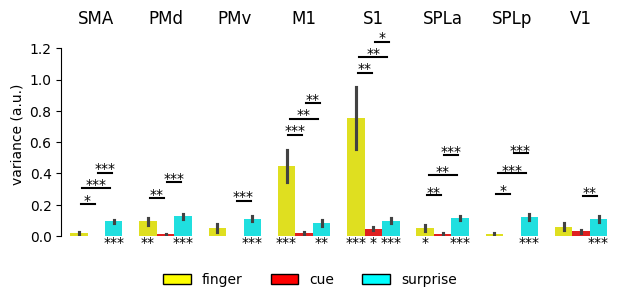

In [46]:
from vis import plot_var_expl, add_sig_var_expl

Mc, idxc = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.exec.p'), 'component')
n_param_c = Mc.n_param
components = ['finger', 'cue', 'surprise']
palette = ['#FFFF00', 'red', 'cyan']
MF = pcm.model.ModelFamily(Mc.Gc, comp_names=components,)
fig, axs = plt.subplots(1, len(rois), figsize=(7, 3), sharey=True, )
for r, roi in enumerate(rois):
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    fig, axs = plot_var_expl(fig, axs, r, param_c, components=components, palette=palette)
for r, roi in enumerate(rois):
    print(f'\n{roi}:')
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    T = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T.model_family.exec.glm{glm}.{H}.{roi}.p'))
    c_bf = MF.component_bayesfactor(T.likelihood, method='AIC', format='DataFrame')
    fig, axs = add_sig_comp_bayes(fig, axs, r, c_bf)
    fig, axs = add_sig_var_expl(fig, axs, r, param_c, components)
    axs[r].set_title(roi)
legend_handles = [Patch(facecolor=col, edgecolor='black', label=comp) for comp, col in zip(components, palette)]
fig.legend(handles=legend_handles, loc='lower center', frameon=False, ncol=len(components), fontsize=10)
fig.subplots_adjust(bottom=.2)
axs[0].spines['left'].set_bounds(axs[0].get_yticks()[0], axs[0].get_yticks()[-2])
plt.show()

M1-S1/prem-pariet ratio, tval=18.186481254058414, pval=1.2558401536027585e-10


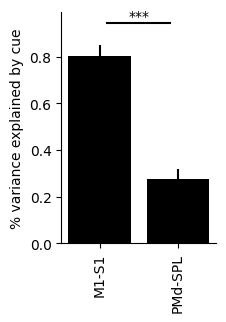

In [47]:
rois_prim = ['M1', 'S1']
rois_high = ['PMd', 'SPLa', 'SPLp']

var_expl_prim = []
for roi in rois_prim:
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    var_expl_prim.append(np.exp(param_c))

var_expl_high = []
for roi in rois_high:
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    var_expl_high.append(np.exp(param_c))

var_expl_prim = np.array(var_expl_prim).mean(axis=0)
var_expl_high = np.array(var_expl_high).mean(axis=0)
ratio_prim = var_expl_prim[0] / (var_expl_prim[-1] + var_expl_prim[0])
ratio_high = var_expl_high[0] / (var_expl_high[-1] + var_expl_high[0])
ratio = np.c_[ratio_prim, ratio_high]
ratio_avg = ratio.mean(axis=0)
ratio_err = ratio.std(axis=0) / np.sqrt(ratio.shape[0])

fig, ax = plt.subplots(figsize=(2, 3))

ax.bar(['M1-S1', 'PMd-SPL'], ratio_avg, yerr=ratio_err, facecolor='k')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xticklabels(labels=['M1-S1', 'PMd-SPL'], rotation=90)
ax.set_ylabel('% variance explained by cue')

tval, pval = ttest_rel(ratio[:, 0], ratio[:, 1], alternative='two-sided')
print(f"M1-S1/prem-pariet ratio, tval={tval}, pval={pval}")
if pval < 0.001:
    stars = '***'
elif pval < 0.01:
    stars = '**'
elif pval < 0.05:
    stars = '*'
else:
    stars = None
if stars:
    y_max = ratio.mean(axis=0).max()
    y_argmax = ratio.mean(axis=0).argmax()
    se = ratio[y_argmax].std() / np.sqrt(ratio.shape[0])
    y_max += se
    y_max0 = y_max
    center = .5
    x1 = center - .4
    x2 = center + .4
    offset = .1 * ax.get_ylim()[1]
    ax.plot([x1, x2], [y_max + offset , y_max + offset], lw=1.5, c='k')
    ax.text(center, y_max + offset, stars, ha='center', va='bottom', fontsize=10)

plt.show()

SMA: correlation=-0.9999988278589587+/-6.047153469193107e-07
PMd: correlation=-0.9999993971198643+/-2.66752816494237e-07
PMv: correlation=-0.9999956656425162+/-1.984666384749652e-06
M1: correlation=-0.9251999596180315+/-0.021612749941371495
S1: correlation=-0.8412272295219286+/-0.03496319931616156
SPLa: correlation=-0.9868760077251811+/-0.012645908635814228
SPLp: correlation=-0.9999994963813856+/-2.2390195065459804e-07
V1: correlation=-0.9904047974453273+/-0.009245457594673899
SMA, tval=-1593515.0101038227, pval=8.84354672523287e-75
PMd, tval=-3612421.2046713848, pval=2.1177639920208852e-79
PMv, tval=-485532.4513845705, pval=4.533348754215408e-68
M1, tval=-41.250881614451885, pval=3.602233735365864e-15
S1, tval=-23.185144883954745, pval=5.842031232975018e-12
SPLa, tval=-75.20041016024263, pval=1.5147605784826654e-18
SPLp, tval=-4303775.0387754515, pval=2.1737631707078512e-80
V1, tval=-103.22668546674082, pval=2.4816946893055036e-20


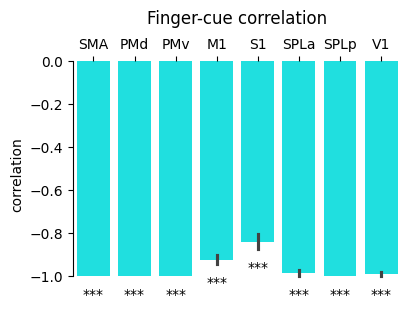

In [48]:
from vis import plot_interaction, add_sig_to_bars

Mf, idxf = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, 'M.exec.p'), 'feature')
n_param_f = Mf.n_param
interaction = {'roi': [], 'interaction': [],}
pcm_path = os.path.join(gl.baseDir, experiment, gl.pcmDir)
for roi in rois:
    f = open(os.path.join(pcm_path, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    theta = param[idxf][:n_param_f]
    theta2 = theta ** 2
    covariance = theta[1] * theta[2]
    stds = np.sqrt((theta2[0] + theta2[1]) * theta2[2])
    correlation = covariance / stds
    print(f'{roi}: correlation={correlation.mean()}+/-{correlation.std() / np.sqrt(correlation.size)}')
    interaction['roi'].extend([roi] * theta.shape[1])
    interaction['interaction'].extend(correlation if (np.isclose(stds, 0).sum() / stds.size) < .6 else [None] * theta.shape[1])

fig, ax = plt.subplots(figsize=(4, 3), constrained_layout=True)
fig, ax = plot_interaction(fig, ax, interaction)
fig, ax = add_sig_to_bars(fig, ax, interaction, y='interaction', x='roi')
ax.spines['left'].set_bounds(ax.get_yticks()[1], ax.get_yticks()[-1])
ax.set_title('Finger-cue correlation', pad=10)
ax.tick_params(axis='x', top=True, labeltop=True, bottom=False, labelbottom=False)
plt.show()

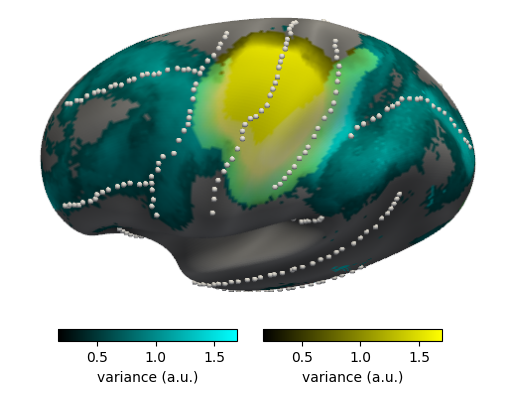

In [76]:
# params
mclip = 0.3
threshold = 0.1 / mclip
scaler = MinMaxScaler()

# load 2 columns only (first and last)
gifti = nb.load(os.path.join(gl.baseDir, experiment, gl.wbDir, f'searchlight.var_expl.exec.{H}.func.gii'))
data = nt.get_gifti_data_matrix(gifti)[:, [0, -1]]   # shape (N, 2)

# raw range for colorbars (original units, before scaling)
raw_max = np.nanmax(data)

# scale to [0,1], then amplify and clip for overlay
data = scaler.fit_transform(data)                    # -> [0,1]
scaled_thr = threshold * mclip                       # value in scaled space *before* the /mclip step
raw_min = scaler.inverse_transform([[scaled_thr, scaled_thr]])[0, 0]

data = np.clip(data / mclip, 0, 1)                   # overlay intensities in [0,1]

# background sulcus shading (grey 0.3–0.7)
sulc = nt.get_gifti_data_matrix(
    nb.load('/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.LR.sulc.dscalar.gii')
)
sulc = sulc[:len(data)]
sulc_norm = MinMaxScaler((0.3, 0.7)).fit_transform(sulc.reshape(-1, 1)).ravel()

# init RGBA with grey background
rgba = np.zeros((len(sulc_norm), 4))
rgba[:, 0] = sulc_norm
rgba[:, 1] = sulc_norm
rgba[:, 2] = sulc_norm
rgba[:, 3] = 1.0

# per-channel masks
mask0 = data[:, 0] >= threshold   # yellow channel active
mask1 = data[:, 1] >= threshold   # cyan channel active
mask_any = mask0 | mask1

# compute blended RGB for active vertices:
# yellow = (R=val0, G=val0), cyan = (G+=val1, B=val1)
r_new = np.zeros(len(data))
g_new = np.zeros(len(data))
b_new = np.zeros(len(data))

r_new[mask0] = data[mask0, 0]
g_new[mask0] = data[mask0, 0]
g_new[mask1] += data[mask1, 1]
b_new[mask1] = data[mask1, 1]

# clamp in case both are strong
g_new = np.clip(g_new, 0, 1)

# write colors only where any overlay is active; keep grey elsewhere
rgba[mask_any, 0] = r_new[mask_any]
rgba[mask_any, 1] = g_new[mask_any]
rgba[mask_any, 2] = b_new[mask_any]
rgba[mask_any, 3] = 1.0

# plot surface with RGB overlay
fig, ax = plt.subplots()
fig, ax = plot_surf(fig, ax, rgba, H, cmap=None, vmin=None, vmax=None, overlay='rgb')

# colorbars: cyan for col1, yellow (#FFFF00) for col0
cyan_half   = LinearSegmentedColormap.from_list("cyan_half",   ["black", "cyan"])
yellow_half = LinearSegmentedColormap.from_list("yellow_half", ["black", "#FFFF00"])

neg_norm = Normalize(vmin=raw_min, vmax=raw_max)  # "negative"/second channel (cyan) range in original units
pos_norm = Normalize(vmin=raw_min, vmax=raw_max)  # "positive"/first channel (yellow) range in original units

sm_neg = ScalarMappable(norm=neg_norm, cmap=cyan_half)    # column 1
sm_pos = ScalarMappable(norm=pos_norm, cmap=yellow_half)  # column 0

# colorbar axes
cax_neg = fig.add_axes([0.20, 0.10, 0.28, 0.025])  # left  (cyan)
cax_pos = fig.add_axes([0.52, 0.10, 0.28, 0.025])  # right (yellow)

cbar_neg = fig.colorbar(sm_neg, cax=cax_neg, orientation='horizontal')
cbar_pos = fig.colorbar(sm_pos, cax=cax_pos, orientation='horizontal')

cbar_neg.set_label('variance (a.u.)')   # column 1
cbar_pos.set_label('variance (a.u.)')   # column 0

plt.show()


SMA
slope: -0.0021255222625483085, p = 0.469
intercept: 0.09459931948429882, p_intercept = 0.004
R2 = 0.001

PMd
slope: -0.017818712993414015, p = 0.327
intercept: 0.14153799068639233, p_intercept = 0.004
R2 = 0.017

PMv
slope: -0.008902363551973734, p = 0.409
intercept: 0.11755756902754948, p_intercept = 0.010
R2 = 0.005

M1
slope: -0.030174984274528215, p = 0.233
intercept: 0.11203431242483852, p_intercept = 0.018
R2 = 0.045

S1
slope: -0.020435088949262804, p = 0.270
intercept: 0.11586270854877036, p_intercept = 0.004
R2 = 0.032

SPLa
slope: 0.015078864299208215, p = 0.674
intercept: 0.10116650783853798, p_intercept = 0.010
R2 = 0.017

SPLp
slope: -0.011876335581044955, p = 0.397
intercept: 0.12993705827722155, p_intercept = 0.014
R2 = 0.006

V1
slope: 0.020855994316764406, p = 0.672
intercept: 0.08810021428554587, p_intercept = 0.083
R2 = 0.017


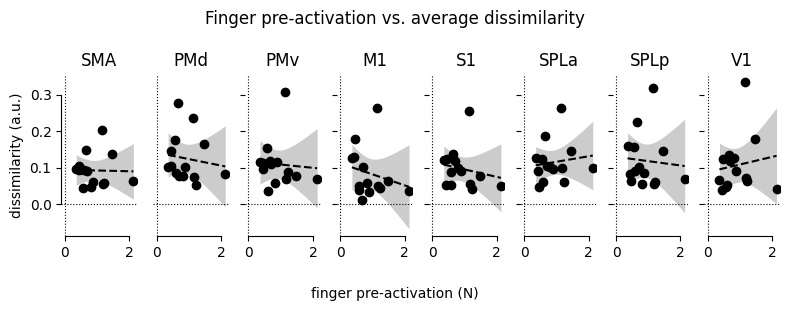

In [49]:
from vis import plot_correlation

pcm_path = os.path.join(gl.baseDir, experiment, gl.pcmDir)
behav = pd.read_csv(os.path.join(gl.baseDir, 'smp2', gl.behavDir, 'smp2_force_single_trial.tsv'), sep='\t')
behav = behav.groupby(['sn', 'stimFinger', 'cue', 'GoNogo']).mean(numeric_only=True).reset_index()
behav = behav[((behav.stimFinger=='index') & (behav.cue=='25-75%')) | ((behav.stimFinger=='ring') & (behav.cue=='75-25%'))]
behav = behav.groupby('sn').mean(numeric_only=True).reset_index()
x = behav.MD

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(8, 3))

for r, roi in enumerate(rois):
    print(f'\n{roi}')
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    var_expl = np.exp(param_c)
    # theta = param[idxf][:n_param_f]
    # theta2 = theta ** 2
    # covariance = theta[1] * theta[2]
    # stds = np.sqrt((theta2[0] + theta2[1]) * theta2[2])
    # correlation = covariance / stds
    y = var_expl[2]
    fig, axs =  plot_correlation(fig, axs, r, x, y, alternative_slope='less', alternative_intercept='two-sided')
    axs[r].set_title(roi)

for ax in axs:
    yticks = ax.get_yticks()
    xticks = ax.get_xticks()
    ax.spines['left'].set_bounds(yticks[1], yticks[-2])
    ax.spines['bottom'].set_bounds(xticks[1], xticks[-2])

axs[0].set_ylabel('dissimilarity (a.u.)', fontsize=10)
axs[1].tick_params('y', left=False)
fig.supxlabel('finger pre-activation (N)', fontsize=10)

fig.suptitle('Finger pre-activation vs. average dissimilarity')

fig.tight_layout()

plt.show()

group estimate:0.16166860564112248 central 90% CI for r: [-1.000, -1.000]
group estimate:-0.34065963421359396 central 90% CI for r: [-0.530, -0.188]
group estimate:-0.9999999878670197 central 90% CI for r: [-1.000, -0.598]
group estimate:0.6377649766746591 central 90% CI for r: [0.542, 0.708]
group estimate:0.6260546784849649 central 90% CI for r: [0.519, 0.719]
group estimate:-0.7419335144518395 central 90% CI for r: [-0.987, -0.579]
group estimate:-1.0 central 90% CI for r: [-1.000, -0.703]
group estimate:0.3497705657534667 central 90% CI for r: [0.197, 0.467]


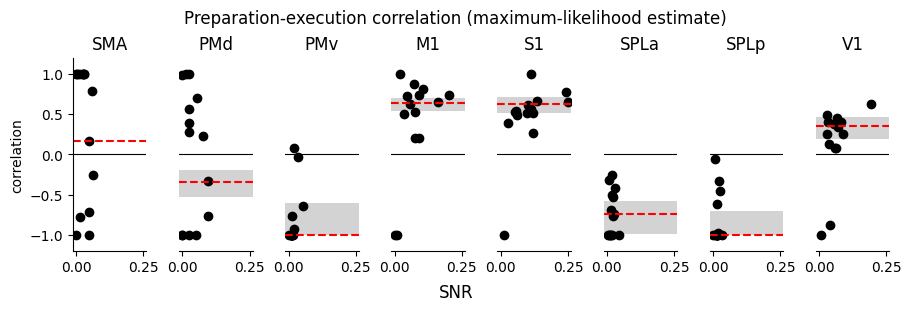

In [50]:
from vis import plot_pcm_corr

f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan-exec.p'), "rb")
Mflex = pickle.load(f)

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(9, 3), constrained_layout=True)

for r, roi in enumerate(rois):
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.corr_plan-exec.glm{glm}.{H}.{roi}.p'), 'rb')
    theta = pickle.load(f)[0]
    r_bootstrap = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'r_bootstrap.corr_plan-exec.{H}.{roi}.npy'))
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_gr.corr_plan-exec.glm{glm}.{H}.{roi}.p'), 'rb')
    theta_g = pickle.load(f)[0]
    fig, axs = plot_pcm_corr(fig, axs, r, Mflex, theta, theta_g, r_bootstrap)
    axs[r].set_title(roi)

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Preparation-execution correlation (maximum-likelihood estimate)')

plt.show()


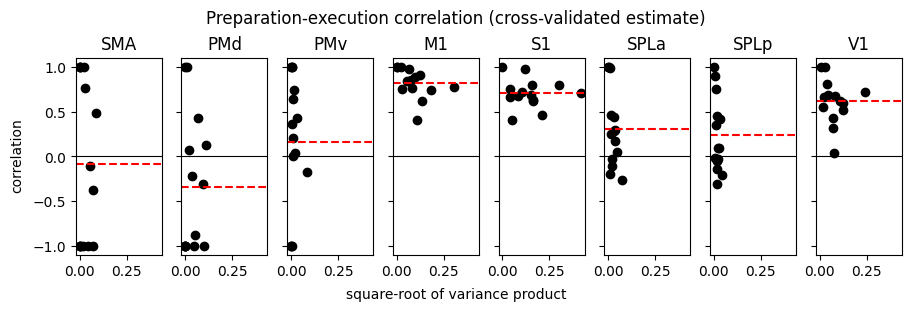

In [51]:
fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(9, 3), constrained_layout=True)
for r, roi in enumerate(rois):
    ax = axs[r]
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.corr_plan-exec.glm{glm}.{H}.{roi}.npy'))
    cov = G[:, 0, 1]
    var1 = np.clip(G[:, 0, 0], 0, None)
    var2 = np.clip(G[:, 1, 1], 0, None)
    corr = np.clip(cov / np.sqrt(var1 * var2), -1, 1)
    ax.axhline(corr.mean(), color='r', ls='--')
    ax.axhline(0, color='k', lw=.8)
    ax.scatter(np.sqrt(var1 * var2), corr, color='k')
    ax.set_title(roi)

fig.suptitle('Preparation-execution correlation (cross-validated estimate)')
fig.supxlabel('square-root of variance product', fontsize=10)
fig.supylabel('correlation', fontsize=10)
# fig.tight_layout()

plt.show()

group estimate:-0.9999999999996398 central 90% CI for r: [-1.000, -1.000]
group estimate:-0.9999999999998829 central 90% CI for r: [-1.000, -1.000]
group estimate:-0.9999999998441083 central 90% CI for r: [-1.000, -1.000]
group estimate:-0.7979095206558834 central 90% CI for r: [-1.000, -0.686]
group estimate:-0.6015298735646122 central 90% CI for r: [-0.762, -0.535]
group estimate:-0.9999999973941862 central 90% CI for r: [-1.000, -1.000]
group estimate:-0.9999999999999151 central 90% CI for r: [-1.000, -1.000]
group estimate:-0.9999999999999437 central 90% CI for r: [-1.000, -1.000]


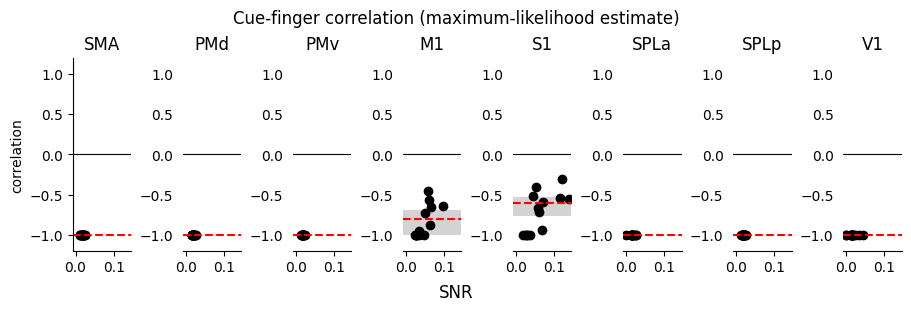

In [52]:
fig, axs = plt.subplots(1, len(rois), sharex=True, figsize=(9, 3), constrained_layout=True)

for r, roi in enumerate(rois):
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.corr_cue-finger.glm{glm}.{H}.{roi}.p'), 'rb')
    theta = pickle.load(f)[0]
    r_bootstrap = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'r_bootstrap.corr_cue-finger.{H}.{roi}.npy'))
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_gr.corr_cue-finger.glm{glm}.{H}.{roi}.p'), 'rb')
    theta_g = pickle.load(f)[0]
    fig, axs = plot_pcm_corr(fig, axs, r, Mflex, theta, theta_g, r_bootstrap)
    axs[r].set_title(roi)

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Cue-finger correlation (maximum-likelihood estimate)')

plt.show()


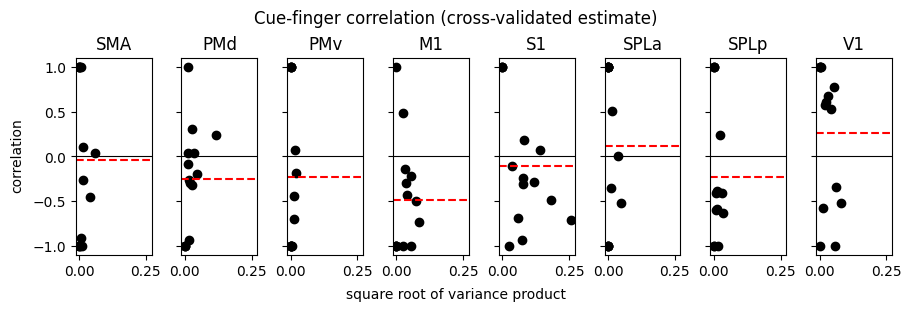

In [53]:
fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(9, 3), constrained_layout=True)
for r, roi in enumerate(rois):
    ax = axs[r]
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.corr_cue-finger.glm{glm}.{H}.{roi}.npy'))
    cov = G[:, 0, 1]
    var1 = np.clip(G[:, 0, 0], 0, None)
    var2 = np.clip(G[:, 1, 1], 0, None)
    corr = np.clip(cov / np.sqrt(var1 * var2), -1, 1)
    ax.axhline(corr.mean(), color='r', ls='--')
    ax.axhline(0, color='k', lw=.8)
    ax.scatter(np.sqrt(var1 * var2), corr, color='k')
    ax.set_title(roi)

fig.suptitle('Cue-finger correlation (cross-validated estimate)')
fig.supxlabel('square root of variance product', fontsize=10)
fig.supylabel('correlation', fontsize=10)
# fig.tight_layout()

plt.show()

group estimate:-0.9999999999999343 central 90% CI for r: [-1.000, -1.000]
group estimate:-0.9999999999999493 central 90% CI for r: [-1.000, -1.000]
group estimate:-0.9999999999999165 central 90% CI for r: [-1.000, -1.000]
group estimate:-0.9999999999998308 central 90% CI for r: [-1.000, -1.000]
group estimate:-0.9999999999999157 central 90% CI for r: [-1.000, -1.000]
group estimate:-0.99999999999987 central 90% CI for r: [-1.000, -1.000]
group estimate:-0.9999999999999667 central 90% CI for r: [-1.000, -1.000]
group estimate:-0.9999999949435642 central 90% CI for r: [-1.000, -1.000]


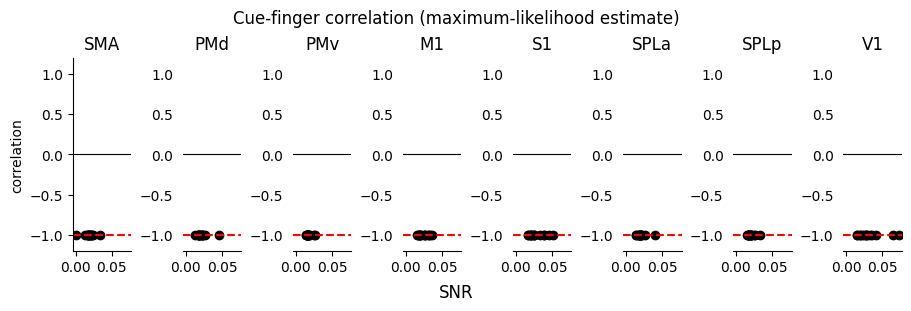

In [57]:
fig, axs = plt.subplots(1, len(rois), sharex=True, figsize=(9, 3), constrained_layout=True)

for r, roi in enumerate(rois):
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.corr_cue-cue.glm{glm}.{H}.{roi}.p'), 'rb')
    theta = pickle.load(f)[0]
    r_bootstrap = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'r_bootstrap.corr_cue-cue.{H}.{roi}.npy'))
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_gr.corr_cue-cue.glm{glm}.{H}.{roi}.p'), 'rb')
    theta_g = pickle.load(f)[0]
    fig, axs = plot_pcm_corr(fig, axs, r, Mflex, theta, theta_g, r_bootstrap)
    axs[r].set_title(roi)

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Cue-finger correlation (maximum-likelihood estimate)')

plt.show()


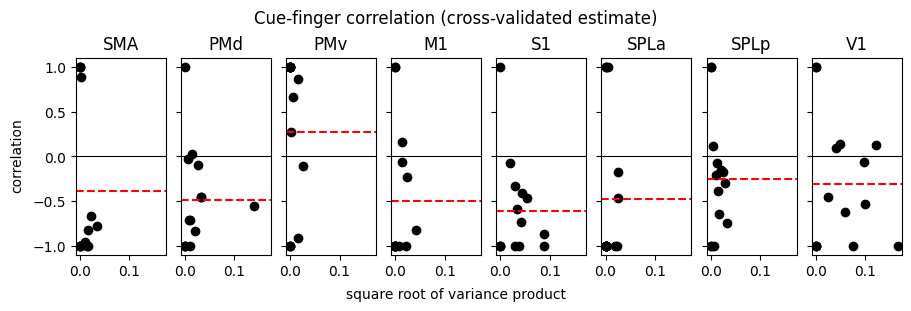

In [58]:
fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(9, 3), constrained_layout=True)
for r, roi in enumerate(rois):
    ax = axs[r]
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.corr_cue-cue.glm{glm}.{H}.{roi}.npy'))
    cov = G[:, 0, 1]
    var1 = np.clip(G[:, 0, 0], 0, None)
    var2 = np.clip(G[:, 1, 1], 0, None)
    corr = np.clip(cov / np.sqrt(var1 * var2), -1, 1)
    ax.axhline(corr.mean(), color='r', ls='--')
    ax.axhline(0, color='k', lw=.8)
    ax.scatter(np.sqrt(var1 * var2), corr, color='k')
    ax.set_title(roi)

fig.suptitle('Cue-finger correlation (cross-validated estimate)')
fig.supxlabel('square root of variance product', fontsize=10)
fig.supylabel('correlation', fontsize=10)
# fig.tight_layout()

plt.show()

SMA: tval=6.731208214277816, pval=1.4020195453022117e-05
PMd: tval=6.351627443100002, pval=2.5291087510591657e-05
PMv: tval=7.219871290806606, pval=6.748403938422488e-06
M1: tval=6.496787970160212, pval=2.013639427769345e-05
S1: tval=5.942273156334609, pval=4.885449351331808e-05
SPLa: tval=6.13906521756044, pval=3.549642779092757e-05
SPLp: tval=6.372813425515391, pval=2.445921913361114e-05
V1: tval=7.794595277252719, pval=2.9694357272503596e-06


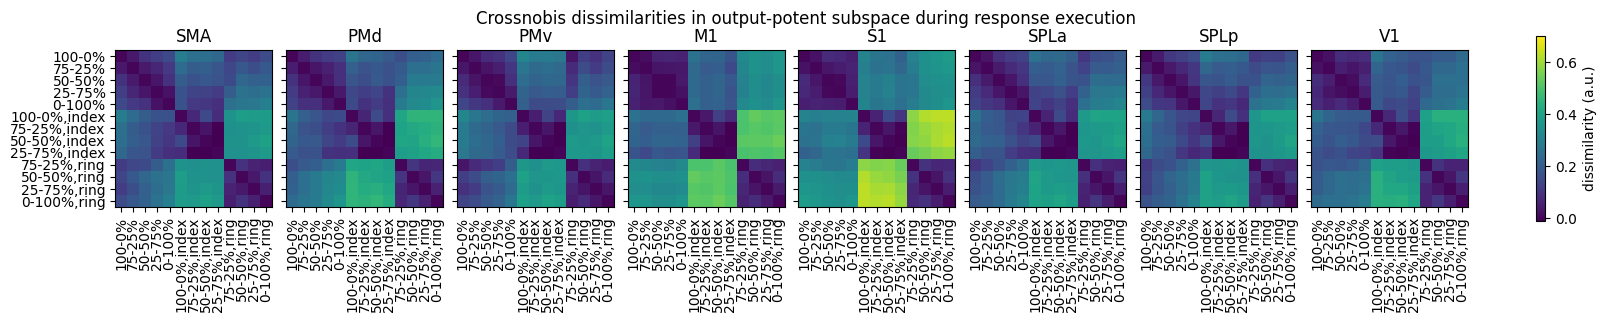

In [55]:
vmin, vmax = -.01, .7

fig, axs = plt.subplots(1, len(rois), figsize=(16, 3),sharex=True, sharey=True, constrained_layout=True)
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.pot.plan-exec.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G)
    fig, axs = plot_dissimilarities(fig, axs, r, D, list(gl.regressor_mapping.keys()), vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle('Crossnobis dissimilarities in output-potent subspace during response execution')

plt.show()

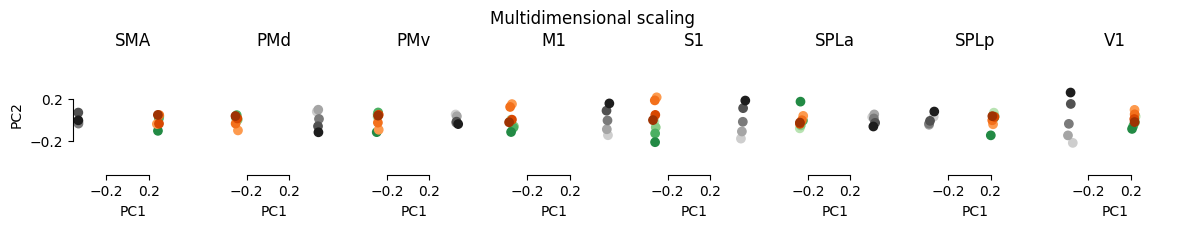

In [133]:
fig, axs = plt.subplots(1, len(rois), figsize=(12, 2),sharex=True, sharey=True, constrained_layout=True)
for r, roi in enumerate(rois):
    ax=axs[r]
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.null.plan-exec.glm{glm}.{H}.{roi}.npy'))
    mds, _ = pcm.classical_mds(G.mean(axis=0))
    ax.scatter(mds[:, 0], mds[:, 1], color=list(gl.colour_mapping.values()))
    ax.set_aspect('equal')
    ax.set_ylim(ax.get_xlim())
    ax.set_xlabel('PC1')
    ax.set_title(roi)
    ax.set_xticks([-.2, .2])
    ax.set_yticks(ax.get_xticks())
    ax.spines[['left', 'top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_bounds(-.2, .2)
    if r==0:
        ax.spines['left'].set_visible(True)
        ax.set_ylabel('PC2')
    else:
        ax.tick_params(axis='y', left=False)

fig.suptitle('Multidimensional scaling')
fig.tight_layout()

plt.show()